In [8]:
import sys
sys.path.insert(0, '../')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import jax
import jax.numpy as jnp

from tools.geometry import generate_detector
from tools.simulation import DetectorSimulator
from tools.particle_generator import generate_muon_track
from tools.loader import build_deposit_data

In [9]:
# ── Track parameters ──────────────────────────────────────────────────────────
DIRECTION      = (1.0, 1.0, 1.0)
KINETIC_ENERGY = 100.0   # MeV
STEP_SIZE_MM   = 0.1

CONFIG_PATH       = '../config/cubic_wireplane_config.yaml'
GT_VELOCITY_CM_US = 0.160
GT_LIFETIME_US    = 10_000.0
N_SEGMENTS        = 50_000

In [10]:
# ── Detector + simulator ──────────────────────────────────────────────────────
# differentiable=True is required for simulator.forward() to work
# (it sets up _forward_diff internally)
detector_config = generate_detector(CONFIG_PATH)
simulator = DetectorSimulator(
    detector_config,
    differentiable=True,
    n_segments=N_SEGMENTS,
    include_noise=False,
    include_electronics=False,
    include_track_hits=False,
    include_digitize=False,
)

cfg        = simulator.config
sim_params = simulator.default_sim_params._replace(
    velocity_cm_us=jnp.array(GT_VELOCITY_CM_US),
    lifetime_us=jnp.array(GT_LIFETIME_US),
)

print('Warming up JIT...')
simulator.warm_up()
print('Done')

--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=50,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Warming up JIT...
Triggering JIT compilation...
JIT compilation finished (total_pad=50,000, iterate=scan).
Done


In [11]:
# ── Generate track + deposits ─────────────────────────────────────────────────
track = generate_muon_track(
    start_position_mm=(0.0, 0.0, 0.0),
    direction=DIRECTION,
    kinetic_energy_mev=KINETIC_ENERGY,
    step_size_mm=STEP_SIZE_MM,
    track_id=1,
)
deposits = build_deposit_data(
    track['position'], track['de'], track['dx'], simulator.config,
    theta=track['theta'], phi=track['phi'],
    track_ids=track['track_id'],
)

for v, vol in enumerate(deposits.volumes):
    print(f'Volume {v}: {vol.n_actual:,} deposits')

Volume 0: 0 deposits
Volume 1: 2,973 deposits


In [ ]:
# ── Forward pass → wire-plane signals ────────────────────────────────────────
signals = simulator.forward(sim_params, deposits)
jax.block_until_ready(signals)
# Signals: tuple of 6 arrays (U0, V0, Y0, U1, V1, Y1), each (n_wires, n_time)
print('Signal shapes:', [s.shape for s in signals])

Signal shapes: [(1969, 2701), (1969, 2701), (1969, 2701), (1969, 2701), (1969, 2701), (1969, 2701)]


In [13]:
# ── Bucket geometry helpers ───────────────────────────────────────────────────
# Deposits are in LOCAL volume coordinates (from build_deposit_data):
#   x_local = drift_dir * (x_anode - x_global)  → distance from anode (≥ 0)
#   y_local = y_global - y_center                → centered
#   z_local = z_global - z_center                → centered
#
# Wire index: round((y*sin(θ) + z*cos(θ)) / wire_spacing) + index_offset
# Time bin:   floor((x_local - plane_dist) / velocity / time_step)
#             plane_distances_cm[i] = distance of plane from anode in local coords

PLANE_LABELS = ['U', 'V', 'Y']

def compute_deposit_wire_time(deposits_vol, vol_geom, cfg, sim_params, plane_idx):
    """Return (wire_idx, time_bin) for all real deposits in one volume/plane."""
    pos_mm = np.array(deposits_vol.positions_mm[:deposits_vol.n_actual])

    x_local_cm = pos_mm[:, 0] / 10.0
    y_local_cm = pos_mm[:, 1] / 10.0
    z_local_cm = pos_mm[:, 2] / 10.0

    angle      = float(vol_geom.angles_rad[plane_idx])
    spacing    = float(vol_geom.wire_spacings_cm[plane_idx])
    offset     = int(vol_geom.index_offsets[plane_idx])
    # plane_distances_cm[i] = distance of plane i from anode = x_local of that plane
    plane_x_cm = float(vol_geom.plane_distances_cm[plane_idx])

    r_prime  = y_local_cm * np.sin(angle) + z_local_cm * np.cos(angle)
    wire_idx = np.round(r_prime / spacing).astype(int) + offset

    drift_dist = np.maximum(x_local_cm - plane_x_cm, 0.0)
    drift_time = drift_dist / float(sim_params.velocity_cm_us)
    time_bin   = np.floor(drift_time / float(cfg.time_step_us)).astype(int)

    return wire_idx, time_bin


def get_active_buckets(wire_idx, time_bin, kernel):
    """Return (active_set, B1, B2, wire_zero, time_zero) for one plane."""
    B1 = 2 * kernel.num_wires
    B2 = 2 * kernel.kernel_height
    wz = kernel.wire_zero_bin
    tz = kernel.time_zero_bin

    active = set()
    for w, t in zip(wire_idx, time_bin):
        hw = (int(w) - wz) // B1
        ht = (int(t) - tz) // B2
        for dw in (0, 1):
            for dt in (0, 1):
                active.add((hw + dw, ht + dt))
    return active, B1, B2, wz, tz

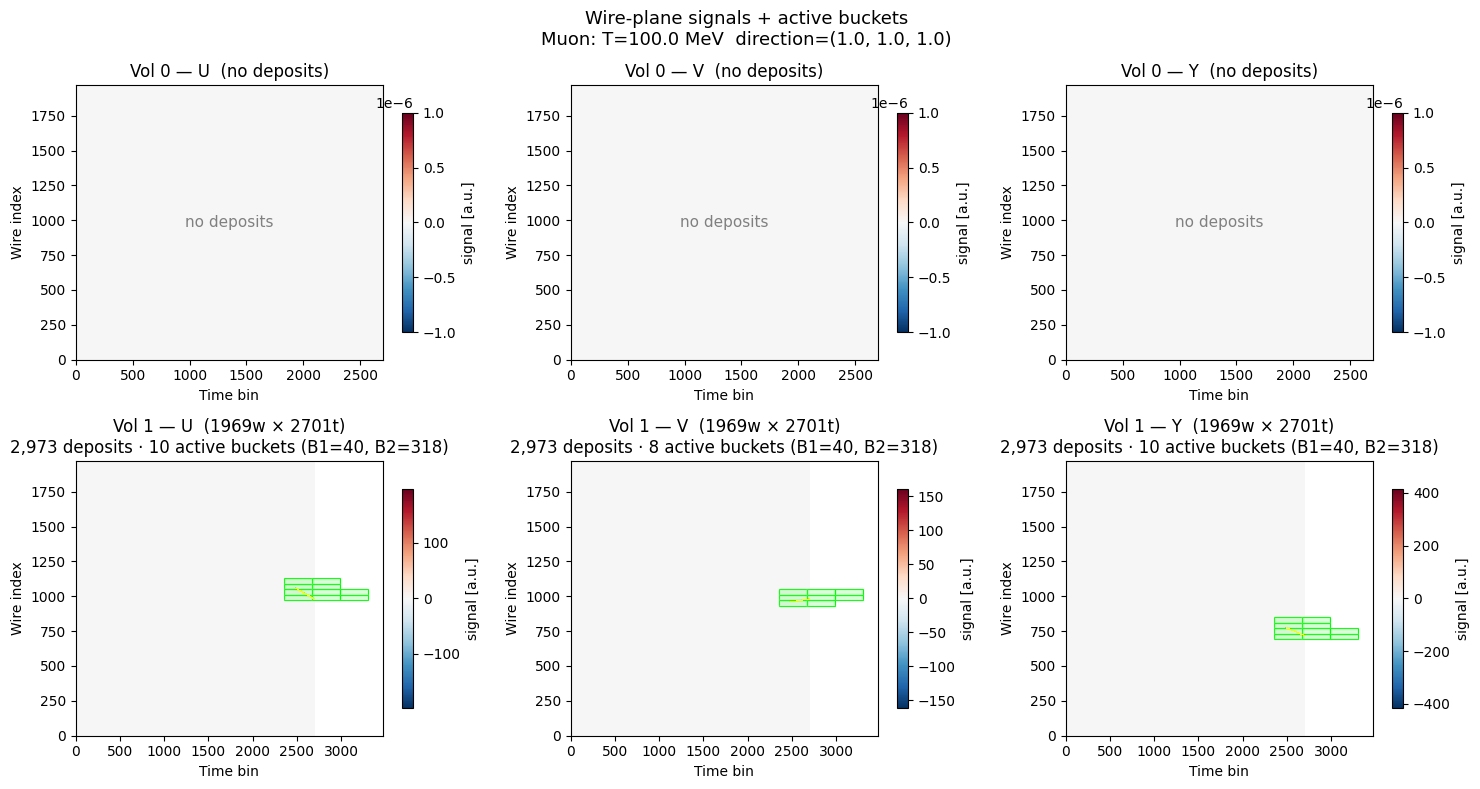

Saved simulation_buckets.png


In [14]:
# ── Visualisation ─────────────────────────────────────────────────────────────
n_volumes = cfg.n_volumes
n_planes  = cfg.volumes[0].n_planes

fig, axes = plt.subplots(n_volumes, n_planes,
                          figsize=(5 * n_planes, 4 * n_volumes),
                          squeeze=False)
fig.suptitle(
    f'Wire-plane signals + active buckets\n'
    f'Muon: T={KINETIC_ENERGY} MeV  direction={DIRECTION}',
    fontsize=13,
)

for v in range(n_volumes):
    vol_geom   = cfg.volumes[v]
    deposits_v = deposits.volumes[v]

    for p in range(n_planes):
        ax          = axes[v][p]
        plane_label = PLANE_LABELS[p]
        kernel      = simulator.response_kernels[plane_label]
        signal      = np.array(signals[v * n_planes + p])   # (n_wires, n_time)
        n_wires, n_time = signal.shape

        # ── Signal image ──────────────────────────────────────────────────────
        vmax = max(np.abs(signal).max(), 1e-6)
        im = ax.imshow(
            signal,
            aspect='auto', origin='lower',
            extent=[0, n_time, 0, n_wires],
            cmap='RdBu_r', vmin=-vmax, vmax=vmax,
            interpolation='nearest',
        )
        plt.colorbar(im, ax=ax, shrink=0.8, label='signal [a.u.]')
        ax.set_xlabel('Time bin')
        ax.set_ylabel('Wire index')

        if deposits_v.n_actual == 0:
            ax.set_title(f'Vol {v} — {plane_label}  (no deposits)')
            ax.text(0.5, 0.5, 'no deposits', transform=ax.transAxes,
                    ha='center', va='center', color='gray', fontsize=11)
            continue

        # ── Deposit positions in wire/time space ───────────────────────────────
        wire_idx, time_bin = compute_deposit_wire_time(
            deposits_v, vol_geom, cfg, sim_params, p)

        # ── Active buckets ─────────────────────────────────────────────────────
        active, B1, B2, wz, tz = get_active_buckets(wire_idx, time_bin, kernel)

        for (bw, bt) in active:
            wire_lo = bw * B1 + wz
            time_lo = bt * B2 + tz
            ax.add_patch(mpatches.Rectangle(
                (time_lo, wire_lo), B2, B1,
                linewidth=0.8, edgecolor='lime', facecolor='lime', alpha=0.15,
            ))
            ax.add_patch(mpatches.Rectangle(
                (time_lo, wire_lo), B2, B1,
                linewidth=0.8, edgecolor='lime', facecolor='none',
            ))

        # ── Tile grid ──────────────────────────────────────────────────────────
        for bw in range((n_wires - wz) // B1 + 2):
            w = bw * B1 + wz
            if 0 <= w <= n_wires:
                ax.axhline(w, color='white', lw=0.3, alpha=0.4)
        for bt in range((n_time - tz) // B2 + 2):
            t = bt * B2 + tz
            if 0 <= t <= n_time:
                ax.axvline(t, color='white', lw=0.3, alpha=0.4)

        # ── Deposit scatter ────────────────────────────────────────────────────
        ax.scatter(time_bin, wire_idx, s=0.3, c='yellow', alpha=0.5, linewidths=0)

        ax.set_title(
            f'Vol {v} — {plane_label}  ({n_wires}w × {n_time}t)\n'
            f'{deposits_v.n_actual:,} deposits · {len(active)} active buckets '
            f'(B1={B1}, B2={B2})'
        )

plt.tight_layout()
plt.savefig('simulation_buckets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved simulation_buckets.png')